# Fundamentos de Ciencia de Datos - FCEx - UNICEN

# Unidad 3: Acceso a datos y análisis

## Clase Práctica 4: Acceso a datos y análisis (parte III)

En la clase pasada aprendimos bastante sobre análisis bivariado, y empezamos a utilizar algunas herramientas de Pandas que nos permiten estudiar los datos un poco más en profundidad.

En la clase de hoy nos vamos a enfocar en esos datos sucios, que no vienen tan buenos como los que usamos previamente, donde necesitamos hacer un esfuerzo mayor por limpiarlos para poder hacer un análisis que tenga algo de sentido.

## 0 - Descarguemos datos nuevos

Muy bonito el dataset de Boston, pero sabemos que no tiene mucha mugre como para que podamos practicar algo más o menos loco. Así que vamos a trabajar toda la clase de hoy con un conjunto nuevo, que sacamos de [Kaggle](https://www.kaggle.com/datasets/rashikrahmanpritom/data-science-job-posting-on-glassdoor?select=Uncleaned_DS_jobs.csv), una plataforma para compartir datos para aprender... Ciencia de Datos ;).

El conjunto con el que trabajaremos tiene información sobre posiciones laborales para Científicos de Datos (Data Scientists) en empresas. Fue descargado de [Glassdoor](https://www.glassdoor.com.ar/index.htm), una de las plataformas más conocidas para búsqueda de empleo en el exterior, donde diferentes empresas publican sus necesidades de staff, y los trabajadores aplican a esas posiciones.

Descarguémoslo y veamos qué tiene:

In [ ]:
# instalamos el paquete para descargar archivos wget
!pip install wget

# importamos wget y las librerías que nos faltan
from wget import download
from os import path
import pandas as pd

# descargamos la base de datos
if not path.exists("Uncleaned_DS_jobs.csv"):
  download("https://ignaciorlando.github.io/datasets/data-science/Uncleaned_DS_jobs.csv")
else:
  print("No vamos a bajar el archivo de itunes porque ya existe!")


No vamos a bajar el archivo de itunes porque ya existe!


In [ ]:
# la abrimos usando Pandas
raw_dataset = pd.read_csv("Uncleaned_DS_jobs.csv")
raw_dataset.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


De la documentación del conjunto, sabemos lo siguiente:

- ```Job Title```: nombre del rol buscado.
- ```Salary Estimation```: rango salarial de ese rol.
- ```Job Description```: descripción completa del rol que se está buscando.
- ```Rating```: qué tan bien ranqueada está esa posición (entre 0 y 5 puntos).
- ```Company```: nombre de la compañía que está buscando ese rol.
- ```Location```: ubicación de la compañía
- ```Headquarter```: ubicación de las oficinas centrales.
- ```Size```: tamaño total de la compañía.
- ```Founded```: año en que fue fundada.
- ```Type of ownership```: tipo de compañía (*non-profit* por ejemplo es una organización sin fines de lucro, *public* es una compañía con acciones en la bolsa, *private* es una compañía privada, etc.).
- ```Industry```: industria en la que trabaja la compañía.
- ```Sector```: sector dentro de la industria en el que se desenvuelve la compañía.
- ```Revenue```: ganancias de la compañía.
- ```Competitors```: lista de competidores.

Vamos a ir viendo con qué nos encontramos. Antes de avanzar, hagamos un ```info()``` para revisar los tipos de datos:

In [ ]:
raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    object 
 2   Salary Estimate    672 non-null    object 
 3   Job Description    672 non-null    object 
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    object 
 6   Location           672 non-null    object 
 7   Headquarters       672 non-null    object 
 8   Size               672 non-null    object 
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    object 
 11  Industry           672 non-null    object 
 12  Sector             672 non-null    object 
 13  Revenue            672 non-null    object 
 14  Competitors        672 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 78.9+ KB


## 1 - Cómo eliminar una columna

Vamos a ver que en algunos casos, recibiremos datos con columnas que no tienen interés para nosotros. Por ejemplo, en este caso, el archivo CSV se leyó incorporando una columna ```index```, que no necesitamos para el análisis posterior.

¿Cómo se borra? Muy fácil: usamos el método ```drop```, que nos pide que indiquemos la columna que queremos borrar, y el eje en la que se encuentra. ```drop``` también puede usarse para eliminar valores puntuales, pero por ahora sólo nos interesa borrar esto:

In [ ]:
raw_dataset = raw_dataset.drop('index', axis=1)
raw_dataset.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


## 2 - Busquemos valores nulos - Pero nulos posta!

Hasta ahora no lo veníamos haciendo, porque nos confiamos bastante en el hecho de que estábamos trabajando con un conjunto de datos bastante limpio. Pero normalmente el primer paso que tenemos que dar (o uno de los primeros, mejor dicho) es explorar si hay valores faltantes en el conjunto.

Podemos hacerlo usando el método ```isna()``` de los ```DataFrame``` en Pandas, que nos indica con un booleano si un valor es ```NaN``` o no, y luego sumar todos esos números.



In [ ]:
# determinamos cuantos nans hay
raw_dataset.isna().sum()

,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,0
Founded,0
Type of ownership,0


A priori pareciera que tenemos todo lo necesario para ponernos contentos, ¿no? Sin embargo, les cuento algo: nos estamos confiando de más.

El ```NaN``` es un valor útil para discernir nulos, pero no necesariamente todos los conjuntos de datos ya van a venir con este dato representándolos.

¿Cómo darnos cuenta, entonces, si en realidad tenemos nulos pero representados de otra forma? Bueno, la solución dependerá de cada conjunto. En este caso, lo haremos estudiando puntualmente los valores únicos de las columnas. Tomemos por caso por ejemplo la columna "Competitors":

In [ ]:
# imprimimos las frecuencias absolutas de cada valor de la columna competitors
raw_dataset["Competitors"].value_counts()

,count
Competitors,
-1,501
"Roche, GlaxoSmithKline, Novartis",10
"Leidos, CACI International, Booz Allen Hamilton",6
"Los Alamos National Laboratory, Battelle, SRI International",6
"Oak Ridge National Laboratory, National Renewable Energy Lab, Los Alamos National Laboratory",3
...,...
"United Natural Foods, US Foods, DPI Specialty Foods",1
"LivePerson, Salesforce, SAP",1
"Zurich Insurance, AXA XL, Allianz",1


Vemos que la columna de ```Competitors``` presenta 501 repeticiones del valor "-1". O bien hay una compañía con bastante inserción en el mercado que lleva ese nombre, o bien evidentemente la representación de un valor nulo en esta columna... es el -1!

Para corregir este problema, debemos entonces reemplazar todas las ocurrencias de ese valor -1 por un ```NaN```:

In [ ]:
import pandas as pd

# copiamos el conjunto para preservarlo
preprocessed_dataset = raw_dataset.copy()
# acomodamos la columna de competitors
preprocessed_dataset['Competitors'] = preprocessed_dataset['Competitors'].replace('-1', pd.NA)


Observen que primero copiamos el DataFrame que teníamos antes (para preservar los datos crudos, por si nos mandamos algún moco!), y que luego usamos el método ```replace```, pasándole como parámetro los valores que queremos intercambiar, y donde el ```NaN``` lo sacamos directamente de dentro de pandas, usando ```pd.NA```.

Ahora, si contamos nulos:

In [ ]:
# determinamos cuantos nans hay ahora en la versión preprocesada
preprocessed_dataset.isna().sum()

,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,0
Founded,0
Type of ownership,0


¿Qué pasa si hacemos esto con la columna ```Size```?

In [ ]:
preprocessed_dataset["Size"].value_counts()

,count
Size,
51 to 200 employees,135
1001 to 5000 employees,104
1 to 50 employees,86
201 to 500 employees,85
10000+ employees,80
501 to 1000 employees,77
5001 to 10000 employees,61
-1,27
Unknown,17


Acá vemos que no tenemos un valor -1 representando un nulo, si no el valor ```Unknown```. Este valor es un nulo para nosotros, porque desconocer el tamaño de la compañía es equivalente a no tener este dato. Para corregirlo, podemos usar el mismo principio que antes, sólo que en lugar de reemplazar al -1, reemplazamos este otro valor:

In [ ]:
preprocessed_dataset["Size"] = preprocessed_dataset["Size"].replace("Unknown", pd.NA)
preprocessed_dataset["Size"] = preprocessed_dataset["Size"].replace("-1", pd.NA)
preprocessed_dataset.isna().sum()

,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,44
Founded,0
Type of ownership,0


¿Y con la columna ```Revenue``` qué pasa?

In [ ]:
preprocessed_dataset["Revenue"].value_counts()

,count
Revenue,
Unknown / Non-Applicable,213
$100 to $500 million (USD),94
$10+ billion (USD),63
$2 to $5 billion (USD),45
$10 to $25 million (USD),41
$1 to $2 billion (USD),36
$25 to $50 million (USD),36
$50 to $100 million (USD),31
$1 to $5 million (USD),31


Nuevamente observamos el mismo problema! Tenemos varios valores repetidos con -1, pero además tenemos otro valor, ```Unknown / Non-applicable```, que también podría eventualmente considerarse como un valor nulo, ¿no? ¿Qué haríamos acá? Bueno, depende realmente del problema. Si a los efectos de los análisis que queremos hacer ambos valores representan un nulo, podemos reemplazarlos:

In [ ]:
import pandas as pd

# reemplazamos -1 y Unknown / Non-Applicable por NaN en la columna Revenue
preprocessed_dataset['Revenue'] = preprocessed_dataset['Revenue'].replace(['-1', 'Unknown / Non-Applicable'], pd.NA)
# determinamos cuantos nans hay ahora en la versión preprocesada
preprocessed_dataset.isna().sum()

,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,44
Founded,0
Type of ownership,0


Observen que en este caso pasamos una lista con los dos valores a reemplazar al método ```replace```, lo que nos ahorra tener que hacer dos líneas seguidas.

Bueno, este mismo procedimiento deberíamos aplicarlo para todas las columnas. ¿Por qué empezamos de atrás para adelante? Porque yo soy zurdo, y tengo un TOC con leer las cosas de atrás para adelante.

Pero revisemos otras, por ejemplo "Rating". Sabemos que es numérica, así que ordenémosla así aparece el -1 bien arriba:

In [ ]:
preprocessed_dataset["Rating"].value_counts().sort_index()


,count
Rating,
-1.0,50
2.0,1
2.1,1
2.2,1
2.3,1
2.4,1
2.5,2
2.6,4
2.7,10


Nuevamente, tenemos 39 nulos. A corregir eso también. Ahora, no copypasteemos la linea de arriba, porque acá tenemos valores numéricos!

In [ ]:
preprocessed_dataset["Rating"] = preprocessed_dataset["Rating"].replace(-1, pd.NA)
preprocessed_dataset["Rating"].value_counts().sort_index()

,count
Rating,
2.0,1
2.1,1
2.2,1
2.3,1
2.4,1
2.5,2
2.6,4
2.7,10
2.8,3


Yo ya sé que otras columnas también tienen -1. Vamos a corregirlas a todas, así no la hacemos tan larga:

In [ ]:
preprocessed_dataset["Founded"] = preprocessed_dataset["Founded"].replace(-1, pd.NA)
preprocessed_dataset["Headquarters"] = preprocessed_dataset["Headquarters"].replace("-1", pd.NA)
preprocessed_dataset["Size"] = preprocessed_dataset["Size"].replace("-1", pd.NA)
preprocessed_dataset["Founded"] = preprocessed_dataset["Founded"].replace("-1", pd.NA)
preprocessed_dataset["Type of ownership"] = preprocessed_dataset["Type of ownership"].replace("-1", pd.NA)
preprocessed_dataset["Industry"] = preprocessed_dataset["Industry"].replace("-1", pd.NA)
preprocessed_dataset["Sector"] = preprocessed_dataset["Sector"].replace("-1", pd.NA)

preprocessed_dataset.isna().sum()

,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,50
Company Name,0
Location,0
Headquarters,31
Size,44
Founded,118
Type of ownership,27


## 3 - Corrijamos variaciones de un mismo valor de variable

Intentemos repetir el análisis de nulos que hicimos anteriormente, pero para la columna ```Job Title```:

In [ ]:
preprocessed_dataset["Job Title"].value_counts()

,count
Job Title,
Data Scientist,337
Data Engineer,26
Senior Data Scientist,19
Machine Learning Engineer,16
Data Analyst,12
...,...
"Sr. Research Associate/ Scientist, NGS prep & Molecular Genomics",1
Developer III - Data Science,1
Hydrogen/Tritium Materials Scientist (Experienced),1


Bueno, acá se nos complicó. Aunque parece que en principio el -1 no aparece, no podemos ver a ciencia cierta todos los valores únicos que existen, porque Pandas no nos imprimió todos los valores. Revisemos si encontramos el -1, a ver:





In [ ]:
preprocessed_dataset["Job Title"][preprocessed_dataset["Job Title"] == "-1"]


,Job Title


Bueno, -1 no tenemos. Ahora, no tenemos garantías de que no aparezca algún string tipo "Unknown" o algo por el estilo. Deberíamos revisar todos los valores de variable, che. Para resolverlo, vamos a tener que imprimir los valores uno por uno nosotros:

In [ ]:
for idx, val in preprocessed_dataset["Job Title"].value_counts().items():
  print(idx, val)

Data Scientist 337
Data Engineer 26
Senior Data Scientist 19
Machine Learning Engineer 16
Data Analyst 12
Senior Data Analyst 6
Senior Data Engineer 5
ENGINEER - COMPUTER SCIENTIST - RESEARCH COMPUTER SCIENTIST - SIGNAL PROCESSING - SAN ANTONIO OR 4
Data Science Software Engineer 4
Data Scientist - TS/SCI FSP or CI Required 4
Senior Business Intelligence Analyst 3
Principal Data Scientist 3
Lead Data Scientist 3
Decision Scientist 3
Data Modeler (Analytical Systems) 3
Senior Machine Learning Scientist - Bay Area, CA 3
Data Scientist - TS/SCI Required 3
Analytics - Business Assurance Data Analyst 3
Senior Data Scientist – Image Analytics, Novartis AI Innovation Lab 3
AI Ops Data Scientist 3
Sr. ML/Data Scientist - AI/NLP/Chatbot 3
Real World Science, Data Scientist 2
Data Scientist - Machine Learning 2
Data Scientist, Applied Machine Learning - Bay Area 2
Product Data Scientist - Ads Data Science 2
Data Scientist - Intermediate 2
Data Analytics Engineer 2
Data Scientist-Human Resources 

Recorriendo la lista, vemos que no tenemos valores nulos. Pero se nos plantea otro problema: vemos, por ejemplo, que hay muchos valores que corresponden al mismo tipo de rol, pero que están expresados de otra manera. Por ejemplo, fíjense todos los que hay que incluyen la palabra "Data Scientist":

In [ ]:
# inicializamos un contador
counter = 0
# creamos una lista para guardar los valores únicos
unique_values = []
# iteramos sobre los valores de la columna
for val in preprocessed_dataset["Job Title"]:
  # si el valor incluye "Data Scientist"
  if "Data Scientist" in val:
    # incrementamos el contador
    counter += 1
    # si el valor no esta en la lista de valores únicos
    if val not in unique_values:
      # lo agregamos
      unique_values.append(val)

# imprimimos el contador y la lista de valores únicos
print("Cantidad de valores que incluyen 'Data Scientist':", counter)
print("Valores únicos:", unique_values)


Cantidad de valores que incluyen 'Data Scientist': 455
Valores únicos: ['Sr Data Scientist', 'Data Scientist', 'Data Scientist / Machine Learning Expert', 'Staff Data Scientist - Analytics', 'Data Scientist - Statistics, Early Career', 'Experienced Data Scientist', 'Data Scientist - Contract', 'Data Scientist/Machine Learning', 'Data Scientist - Risk', 'Data Scientist-Human Resources', 'Senior Research Statistician- Data Scientist', 'Associate Data Scientist', 'Senior Analyst/Data Scientist', 'Senior Data Scientist', 'Product Data Scientist - Ads Data Science', 'Data Scientist - Intermediate', 'Data Scientist - Machine Learning', 'Data Scientist, Applied Machine Learning - Bay Area', 'Principal Data Scientist', 'Data Scientist 3 (718)', 'Real World Science, Data Scientist', 'Data Scientist - Image and Video Analytics', 'Data Scientist / Applied Mathematician', 'Patient Safety- Associate Data Scientist', '(Sr.) Data Scientist -', 'Data Scientist, Kinship - NYC/Portland', 'Applied Techno

Obviamente los diferentes valores incluyen ciertos detalles que agregan algo más de información (por ejemplo, "Sr Data Scientist" hace referencia a un Data Scientist con mayor experiencia. Eliminar esta información adicional puede ser un error, o no, dependiendo del problema.

Podríamos intentar pulir un poco mejor esto de varias maneras distintas. Una es absorber a todos los casos que incluyan la expresión "Data Scientist" es un único valor "Data Scientist", reemplazándolo en el original. Otra alternativa (mi preferida), es incorporar una columna ```is_datascientist```, binaria, que indique si el rol se corresponde a uno de Data Scientist:

In [ ]:
# agregamos una columna is_datascientist
preprocessed_dataset['is_datascientist'] = preprocessed_dataset['Job Title'].apply(lambda x: "Data Scientist" in x)
preprocessed_dataset['is_datascientist'].value_counts()

,count
is_datascientist,
True,455
False,217


Observen que el código para hacerlo no es tan trivial. En este caso usamos el método ```apply``` en un ```DataFrame```, que se utiliza para aplicar una función dado a lo largo de un eje (ya sea filas o columnas). Esa función puede tener un nombre que nosotros hayamos definido previamente, o tratarse de una función anónima.

Funciones anónimas, ok. Se puso heavy la cosa. Tranca, no es tan difícil. Una función anónima es una función de la que conocemos su código, pero a la que decidimos no ponerle un nombre. Sirve por ejemplo para esos casos en los que no se justifica escribir una función entera, porque se van a usar una única vez.

En Python, este tipo de funciones se trabajan como una función ```lambda```. Ésta se define utilizando la palabra clave ```lambda```, seguida de una lista de argumentos, dos puntos (:) y una expresión. La expresión es justamente el cuerpo de la función, y es lo que es evaluado y devuelto como resultado de la función.

En este caso, se aplica una función ```lambda``` a cada elemento de la columna ```Job Title```. La función verifica si la cadena "Data Scientist" está presente en el título del trabajo y devuelve ```True``` o ```False``` en consecuencia. El resultado se almacena luego en la nueva columna ```is_datascientist```. Fíjense que de esta forma nos ahorramos tener que hacer un ```for```, y procesamos el conjunto rapidísimo.

Ahora bien, miremos este caso:

In [ ]:
preprocessed_dataset[preprocessed_dataset["Job Title"] == "Data & Machine Learning Scientist"]


,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,is_datascientist
68,Data & Machine Learning Scientist,$79K-$131K (Glassdoor est.),Passionate about precision medicine and advanc...,3.3,Tempus Labs\n3.3,"Chicago, IL","Chicago, IL",501 to 1000 employees,2015,Company - Private,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,<NA>,<NA>,False
467,Data & Machine Learning Scientist,$31K-$56K (Glassdoor est.),Passionate about precision medicine and advanc...,3.3,Tempus Labs\n3.3,"Chicago, IL","Chicago, IL",501 to 1000 employees,2015,Company - Private,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,<NA>,<NA>,False


Lo que hicimos acá fue buscar registros para un valor específico de ```Job Title```, que es ```Data & Machine Learning Scientist```. Si se fijan, deberíamos tener la columna ```is_datascientist``` en ```True```, pero no ocurre porque bueno, no buscamos exactamente eso. Estos casos requieren un análisis más exhaustivo de nuestra parte. Si quisiéramos resolverlos, deberíamos escribir todas las líneas necesarias para reemplazarlos y corregirlos. Por ejemplo, podríamos modificar la línea de arriba para considerar cualquier caso que incluya la palabra "Scientist":

In [ ]:
# actualizamos la columna is_datascientist: ahora si incluye "scientist" ya nos alcanza
preprocessed_dataset['is_datascientist'] = preprocessed_dataset['Job Title'].apply(lambda x: "scientist" in x or "Scientist" in x)
preprocessed_dataset['is_datascientist'].value_counts()

,count
is_datascientist,
True,512
False,160


## 4 - Hablemos de valores repetidos ~~repetidos~~ ~~repetidos~~ ~~repetidos~~

Ahora bien, justo los dos casos que vimos antes son repetidos, no? ¿Cuántos repetidos tendremos? Contémoslos:


In [ ]:
# contamos la cantidad de duplicados
preprocessed_dataset.duplicated().sum()

np.int64(13)

Guau, 13 repetidos de un total de 672 registros. Un 1.9% de los datos.

Aunque en algunos casos los repetidos nos brindan cierta información, en otros necesitaremos removerlos. Pero, como ya sabemos, eliminar registros es siempre algo que tenemos que hacer con cuidado. Al menos deberíamos imprimir los datos, para saber qué onda:


In [ ]:
# imprimimos las filas duplicadas
preprocessed_dataset[preprocessed_dataset.duplicated(keep=False)]


,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,is_datascientist
131,Senior Data Engineer,$90K-$109K (Glassdoor est.),Lendio is looking to fill a position for a Sen...,4.9,Lendio\n4.9,"Lehi, UT","Lehi, UT",201 to 500 employees,2011,Company - Private,Lending,Finance,$50 to $100 million (USD),<NA>,False
134,Machine Learning Engineer,$90K-$109K (Glassdoor est.),Role Description\nTriplebyte screens and evalu...,3.2,Triplebyte\n3.2,Remote,"San Francisco, CA",51 to 200 employees,2015,Company - Private,Computer Hardware & Software,Information Technology,<NA>,<NA>,False
135,Machine Learning Engineer,$90K-$109K (Glassdoor est.),Role Description\nTriplebyte screens and evalu...,3.2,Triplebyte\n3.2,Remote,"San Francisco, CA",51 to 200 employees,2015,Company - Private,Computer Hardware & Software,Information Technology,<NA>,<NA>,False
136,Senior Data Engineer,$90K-$109K (Glassdoor est.),Lendio is looking to fill a position for a Sen...,4.9,Lendio\n4.9,"Lehi, UT","Lehi, UT",201 to 500 employees,2011,Company - Private,Lending,Finance,$50 to $100 million (USD),<NA>,False
357,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,<NA>,Hatch Data Inc,"San Francisco, CA",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True
358,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,<NA>,Hatch Data Inc,"San Francisco, CA",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True
359,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,<NA>,Hatch Data Inc,"San Francisco, CA",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True
360,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,<NA>,Hatch Data Inc,"San Francisco, CA",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True
361,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,<NA>,Hatch Data Inc,"San Francisco, CA",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True
362,Data Scientist,$122K-$146K (Glassdoor est.),Job Overview: The Data Scientist is a key memb...,<NA>,Hatch Data Inc,"San Francisco, CA",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True


Acá pasamos ```keep=False``` porque queremos marcar todas las ocurrencias repetidas, para poder imprimirlas.

Si quisiéramos eliminarlas, debemos sacar a todas menos una, con lo cual necesitamos pasar ```keep="first"```. Vamos a usar para ello el método ```drop_duplicates()```:

In [ ]:
# eliminamos los duplicados
preprocessed_dataset.drop_duplicates(keep="first", inplace=True)
# contamos la cantidad de duplicados
preprocessed_dataset.duplicated().sum()

np.int64(0)

Listo! No hay más repetidos.

## 5 - Creemos columnas nuevas a partir de otras

Hace un rato ya vimos cómo crear una nueva columna a partir de otra, cuando hicimos la ```is_datascientist```. Podríamos usar el mismo principio para crear otras del estilo, por ejemplo ```is_dataengineer```:

In [ ]:
# agregamos una columna is_dataengineer
preprocessed_dataset['is_dataengineer'] = preprocessed_dataset['Job Title'].apply(lambda x: "Data Engineer" in x)
preprocessed_dataset['is_dataengineer'].value_counts()

,count
is_dataengineer,
False,613
True,46


Pero esto es solamente un ejemplo del tipo de columnas nuevas que podemos crear. Por ejemplo, vimos que en varios de los trabajos tenemos referencias a profesionales Senior. Podríamos generar una columna ```is_senior``` representando si se trata de un senior o no:

In [ ]:
# agregamos una columna is_senior
preprocessed_dataset['is_senior'] = preprocessed_dataset['Job Title'].apply(lambda x: ("senior" in x) or ("Sr" in x) or ("Senior" in x))
preprocessed_dataset['is_senior'].value_counts()

,count
is_senior,
False,584
True,75


También si se fijan en la columna ```Location```, hay varios que se indican con ```Remote```. Podríamos crear una columna que indique si es remoto, también:

In [ ]:
# agregamos una columna is_remote
preprocessed_dataset['is_remote'] = preprocessed_dataset['Job Title'].apply(lambda x: ("remote" in x) or ("Remote" in x))
preprocessed_dataset['is_remote'].value_counts()

,count
is_remote,
False,655
True,4


## 6 - Preprocesemos valores ordinales

Otra de las operaciones de transformación que solemos aplicar sobre los datos es el mapeo de variables ordinales a valores numéricos, que representen mejor esa ordinalidad.

En este caso, tenemos la columna ```Revenue```, que toma estos valores:

In [ ]:
preprocessed_dataset["Revenue"].value_counts()

,count
Revenue,
$100 to $500 million (USD),94
$10+ billion (USD),63
$2 to $5 billion (USD),45
$10 to $25 million (USD),41
$1 to $2 billion (USD),36
$25 to $50 million (USD),36
$1 to $5 million (USD),31
$50 to $100 million (USD),30
$500 million to $1 billion (USD),19


En estos casos, estos strings nos piden a gritos que los tratemos como una variable ordinal. Pero para poder generar ese orden, necesitamos crear un mapeo representativo de estos datos.

Una opción sería unas números consecutivos. Pero si hiciéramos eso, no estaríamos ponderando bien las diferencias de rangos de los valores. En vez de eso, les propongo que usemos el valor de cierre de cada intervalao, y que, a los de más de 10 billion (más de 10.000 millones) los reemplacemos por 20.000.

Para hacer esto, usamos la operación ```map``` de Pandas, pasándole un diccionario:

In [ ]:
revenue_map = {
    'Less than $1 million (USD)': 1,
    '$5 to $10 million (USD)': 10,
    '$10 to $25 million (USD)': 25,
    '$25 to $50 million (USD)': 50,
    '$50 to $100 million (USD)': 100,
    '$100 to $500 million (USD)': 500,
    '$500 million to $1 billion (USD)': 1000,
    '$1 to $2 billion (USD)': 2000,
    '$2 to $5 billion (USD)': 5000,
    '$5 to $10 billion (USD)': 10000,
    '$10+ billion (USD)': 20000,
}
preprocessed_dataset['revenue_ordinal'] = preprocessed_dataset['Revenue'].map(revenue_map)
preprocessed_dataset['revenue_ordinal'].value_counts().sort_index()


,count
revenue_ordinal,
1.0,14
10.0,14
25.0,41
50.0,36
100.0,30
500.0,94
1000.0,19
2000.0,36
5000.0,45


De esta forma, logramos que la variable represente la ordinalidad del conjunto, en este caso medida en millones de dólares.

El mismo principio se puede aplicar para la columna ```Size```:

In [ ]:
preprocessed_dataset["Size"].value_counts()

,count
Size,
51 to 200 employees,134
1001 to 5000 employees,104
1 to 50 employees,86
201 to 500 employees,84
10000+ employees,80
501 to 1000 employees,77
5001 to 10000 employees,61


Por los valores que tenemos acá, nos conviene, en lugar de usar el límite superior, usar el límite inferior, que sabemos que está presente en todos los casos:

In [ ]:
size_map = {
    "1 to 50 employees":	1,
    "51 to 200 employees":	51,
    "201 to 500 employees":	201,
    "501 to 1000 employees":	501,
    "1001 to 5000 employees": 1001,
    "5001 to 10000 employees":	5001,
    "10000+ employees":	10000
}
preprocessed_dataset['size_ordinal'] = preprocessed_dataset['Size'].map(size_map)
preprocessed_dataset['size_ordinal'].value_counts().sort_index()


,count
size_ordinal,
1.0,86
51.0,134
201.0,84
501.0,77
1001.0,104
5001.0,61
10000.0,80


## 7 - Lo último de hoy: variables cualitativas nominales

Convertir variables cualitativas nominales es todo un arte, porque dependiendo de la cantidad de valores con los que contamos, puede convenirnos o bien trabajar con variables dummy (los famosos one-hot encodings), o bien trabajar con variables binarias.

Analicemos, por ejemplo, qué hacer con la variable ```Industry```:

In [ ]:
len(preprocessed_dataset['Industry'].value_counts().index)
#preprocessed_dataset['Industry'].value_counts()

57

Vemos que la cantidad de valores únicos es enorme (57!), con lo que generar variables dummy no es una buena idea. Fíjense cómo nos quedaría el conjunto si lo hiciéramos:

In [ ]:
import pandas as pd
# creamos una copia del dataset
dummy_dataset = preprocessed_dataset.copy()
# creamos variables dummy para la columna Industry
dummy_industry = pd.get_dummies(dummy_dataset['Industry'], prefix='industry')
# concatenamos las variables dummy al dataset original
dummy_dataset = pd.concat([dummy_dataset, dummy_industry], axis=1)
# imprimimos el nuevo dataset
dummy_dataset


,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,industry_Telecommunications Manufacturing,industry_Telecommunications Services,industry_Timber Operations,industry_Transportation Equipment Manufacturing,industry_Transportation Management,industry_Travel Agencies,industry_Utilities,industry_Venture Capital & Private Equity,industry_Video Games,industry_Wholesale
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,...,False,False,False,False,False,False,False,False,False,False
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,...,False,False,False,False,False,False,False,False,False,False
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,...,False,False,False,False,False,False,False,False,False,False
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,...,False,False,False,False,False,False,False,False,False,False
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,...,False,False,False,False,False,False,False,False,False,False
668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,<NA>,JKGT,"San Francisco, CA",<NA>,<NA>,<NA>,<NA>,...,False,False,False,False,False,False,False,False,False,False
669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,<NA>,AccessHope,"Irwindale, CA",<NA>,<NA>,<NA>,<NA>,...,False,False,False,False,False,False,False,False,False,False
670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,<NA>,Company - Private,...,False,False,False,False,False,False,False,False,False,False


Es una locura hacer algo asi! Pero busquemos alguna alternativa más copada. Grafiquemos la distribución de industrias en el conjunto, porque una imagen vale más que mil palabras:

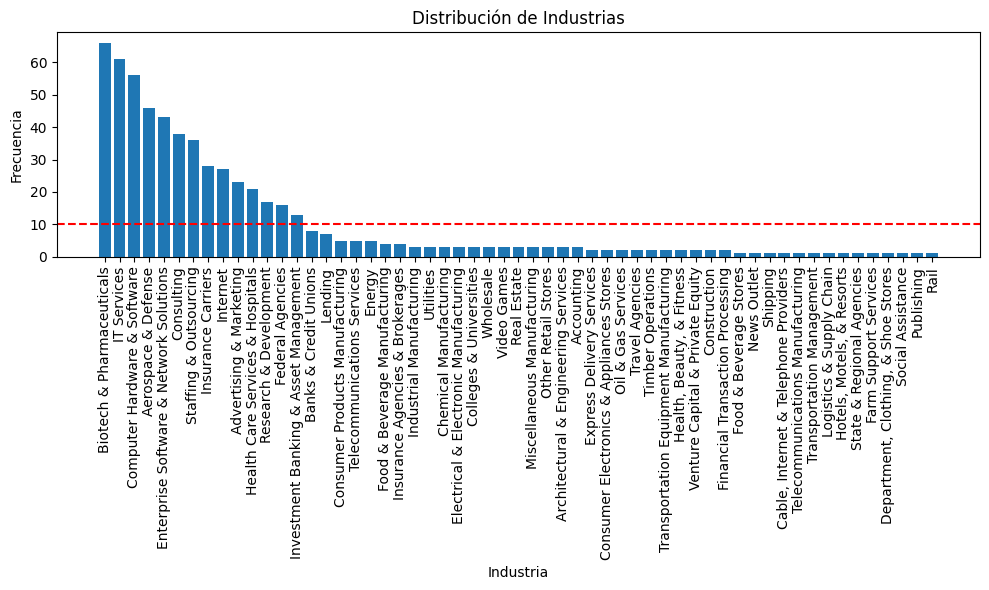

In [ ]:
import matplotlib.pyplot as plt

# contamos las frecuencias de cada valor
industry_counts = preprocessed_dataset['Industry'].value_counts()

# ordenamos las frecuencias de mayor a menor
industry_counts = industry_counts.sort_values(ascending=False)

# graficamos el histograma
plt.figure(figsize=(10, 6))  # Ajusta el tamaño de la figura si es necesario
plt.bar(industry_counts.index, industry_counts.values)
plt.xticks(rotation=90)  # Rota las etiquetas del eje x para mayor legibilidad
plt.xlabel('Industria')
plt.ylabel('Frecuencia')
plt.title('Distribución de Industrias')
plt.axhline(y=10, color='red', linestyle='--')  # Agrega una línea vertical en x=10
plt.tight_layout()  # Ajusta el diseño para evitar superposiciones
plt.show()


A propósito les metí una línea horizontal, que nos marca el valor 10. Si se fijan, la gran mayoría de los valores de variable están por debajo de 10. Eso significa que casi no hay muestras con esos valores, por los que agregar columnas tan ralas (tan llenas de ```False```) no agregaría nada de valor.

Podemos, entonces, crear una columna agrupada, a la que llamaremos ```industry_grouped```, en donde todas aquellas industrias que tengan una frecuencia inferior a 10, se reemplazan por la palabra ```Other```:

In [ ]:
# contamos la frecuencia de cada valor de variable
industry_counts = preprocessed_dataset['Industry'].value_counts()
# nos quedamos con los índices de las que tienen una frecuencia mayor a 10
top_industries = industry_counts[industry_counts >= 10].index
# conservamos los valores que figuran en ese índice, y al resto los reemplazamos por "Other"
preprocessed_dataset['industry_grouped'] = preprocessed_dataset['Industry'].apply(lambda x: x if x in top_industries else 'Other')

preprocessed_dataset["industry_grouped"].value_counts()

,count
industry_grouped,
Other,168
Biotech & Pharmaceuticals,66
IT Services,61
Computer Hardware & Software,56
Aerospace & Defense,46
Enterprise Software & Network Solutions,43
Consulting,38
Staffing & Outsourcing,36
Insurance Carriers,28


Ahora vemos que el valor de variable más frecuente pasó a ser ```Other```. En principio esto no es malo, pero deberíamos recordarlo, porque si observamos algún fenómeno vinculado con ese valor de variable, probablemente debamos expandir esta categoría agrupada, y explorar entonces cómo seguir.

Bueno, es tarde y tengo que hacer la comida. ¿No se enojan si no les hago la variable dummy?

...

Maldita sea, no puedo con mi genio. OK, acá va:

In [ ]:
# generamos las nuevas dummy
dummy_industry = pd.get_dummies(preprocessed_dataset['industry_grouped'], prefix='industry')
# concatenamos las variables dummy al dataset original
preprocessed_dataset = pd.concat([preprocessed_dataset, dummy_industry], axis=1)
# imprimimos el nuevo dataset
preprocessed_dataset

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,industry_Enterprise Software & Network Solutions,industry_Federal Agencies,industry_Health Care Services & Hospitals,industry_IT Services,industry_Insurance Carriers,industry_Internet,industry_Investment Banking & Asset Management,industry_Other,industry_Research & Development,industry_Staffing & Outsourcing
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,...,False,False,False,False,True,False,False,False,False,False
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,...,False,False,False,False,False,False,False,False,True,False
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,...,False,False,False,False,False,False,False,False,False,False
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,...,False,False,False,False,False,False,False,True,False,False
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989,Company - Private,...,False,False,False,False,False,False,False,False,False,False
668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,<NA>,JKGT,"San Francisco, CA",<NA>,<NA>,<NA>,<NA>,...,False,False,False,False,False,False,False,True,False,False
669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,<NA>,AccessHope,"Irwindale, CA",<NA>,<NA>,<NA>,<NA>,...,False,False,False,False,False,False,False,True,False,False
670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,<NA>,Company - Private,...,False,False,False,False,False,False,False,False,False,False


Esto es todo por hoy! Hoy aprendimos a hacer todo ese análisis tedioso que se asocia a los datos sucios: entendimos cómo identificar valores nulos más allá de los NaNs, cómo introducirlos, cómo generar nuevas columnas, cómo derivar valores a partir de columnas ya existentes, y aprendimos a trabajar con variables ordinales y con variables nominales.

No hay más excusas, tenemos todo para empezar el trabajo especial!